In [ ]:
# load Python packages
import numpy as np  # for numerical python libraries
import matplotlib.pyplot as plt  # for plotting
import scipy.stats as stats

In [54]:
# Tests
# X = np.array([[1, 2], [3, 4]])
# #X[0,:] = 1; print(X)
# print(X); print(X[1,0]); print(X[1, :])
# sum(X[1,:])

# tmp = "rah" != "blah"; tmp * 2

# type = "rah"
# if type == "Merton":
#     def jump(x): 1
# elif type == "Kou":
#     def jump(x): 1
# else:
#     def jump(): return 0

# print(type)
# print(jump())

# U = stats.uniform.rvs(); print(U)
# jump = U < (1 - np.exp(-1 * 1)); print(jump)  # interarrival times exponentially dist
# jump_size = stats.gamma.rvs(a=1, scale=1, size=1); print(jump_size)

# A = B = 3; print(A); print(B)

# print(np.zeros(3))
# for i in range(5):
    # print(i)

np.random.binomial(1, 0.5)

np.log(10)

tmp = [1, 1]; print(tmp)

val = 0; print(val)
val += 1; print(val)

np.math.factorial(3)



[1, 1]
0
1


6

In [4]:
## Rough Work
        # jump_size = np.exp(np.random.normal(loc=m, scale=delta, size=Nsims))
        # X[idx+1,:] = X[idx,:] * np.exp((r - sigma**2 / 2 - lam*(np.exp(m + delta**2 / 2) - 1)) * dt +
        #                                sigma * np.sqrt(dt) * Z +
        #                                jump * jump_size)

## Simulation

--
$$
\begin{aligned}
    S_t &= (r - \frac{\sigma^2}{2} - \lambda (e^{m + \frac{\delta^2}{2}} - 1))t + \sigma B_t + \sum_{i=1}^{N_t} Y_i \\
    dS_t &= \mu S_t dt + \sigma S_t dW_t
\end{aligned}
$$

where $B_t$ is standard Brownian motion, $Y_i \sim i.i.d. Lognormal(m, \delta^2)$, and $N_t$ is a poisson process with intensity $\lambda$.

In [ ]:
# Helper functions: Black-Scholes
def sim_jump_diffusion(X0, T, Ndt, mu, sigma, Nsims = 100, type = "BS", lam = 0, m = 0, delta = 0, p = 0.5, eta = [1, 1]):
    ## Basic parameters
    dt = T / Ndt # create time increment
    time = np.linspace(0, T, Ndt+1) # set the different times as a vector
    X = B = np.zeros((Ndt+1,Nsims)) # initialize matrix
    X[0,:] = X0 # initial value of the process
    
    ## Jump generation function
    drift_adj = 0
    def jump_distn(): return 0 # No jumps
    if type == "Merton":
        # Merton: Drift adjustment
        # drift_adj = lam * (np.exp(m + delta**2 / 2) - 1)

        # Generate jumps
        def jump_distn():
            # Number of jumps - Poisson process
            U = stats.uniform.rvs(size=Nsims)
            jump = U < (1 - np.exp(-lam * dt))  # Interarrival times exponentially dist
            # Jump size - Normal distribution
            jump_size = np.random.normal(loc=m, scale=delta, size=Nsims) # Jump size normally distributed
            return jump * jump_size
        
    elif type == "Kou":
        # Kou: Drift adjustment
        # drift_adj = lam * (np.exp(m + delta**2 / 2) - 1)

        def jump_distn():
            # Number of jumps - Poisson process
            U = stats.uniform.rvs(size=Nsims)
            jump = U < (1 - np.exp(-lam * dt))
            # Jump size - Double exponential
            B = np.random.binomial(n = 1, p = p, size = Nsims) # Bernoulli rv - whether jump is positive or negative
            jump_size = np.zeros(Nsims)
            for i in range(Nsims):
                jump_size[i] = (-1)**(B[i] + 1) * np.random.exponential(1/eta[B[i]]) # Jump size exponentially distributed
            return jump * jump_size
        
    
    ## Simulation
    for idx in range(Ndt):
        Z = np.random.randn(Nsims)
        # X[idx+1,:] = X[idx,:] + (r - sigma**2 / 2 - merton) * dt + sigma * np.sqrt(dt) * Z + jump_distn()
        X[idx+1,:] = X[idx,:] * np.exp((mu - sigma**2 / 2 - drift_adj) * dt + sigma * np.sqrt(dt) * Z + jump_distn())
    
    return time, X

## Sample Paths - Moderate Parameters

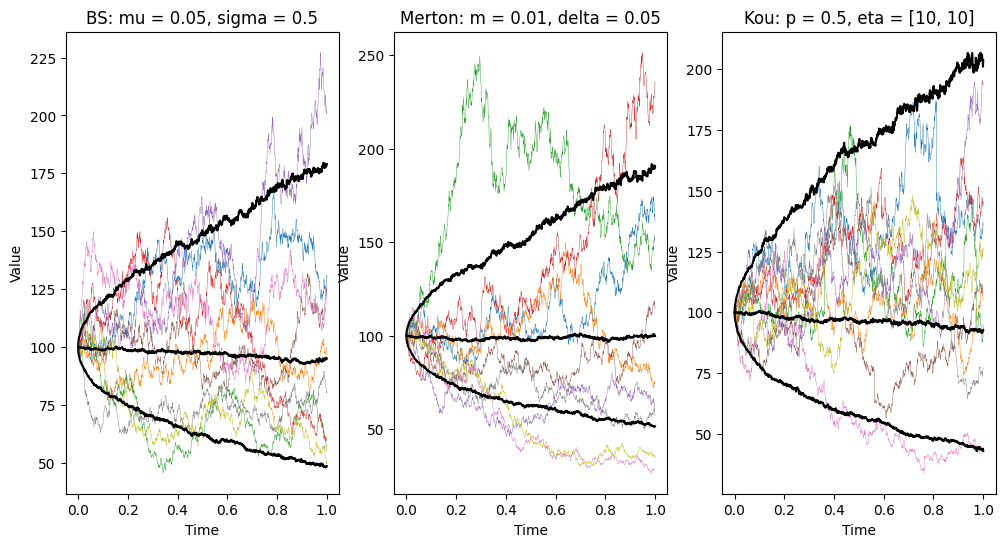

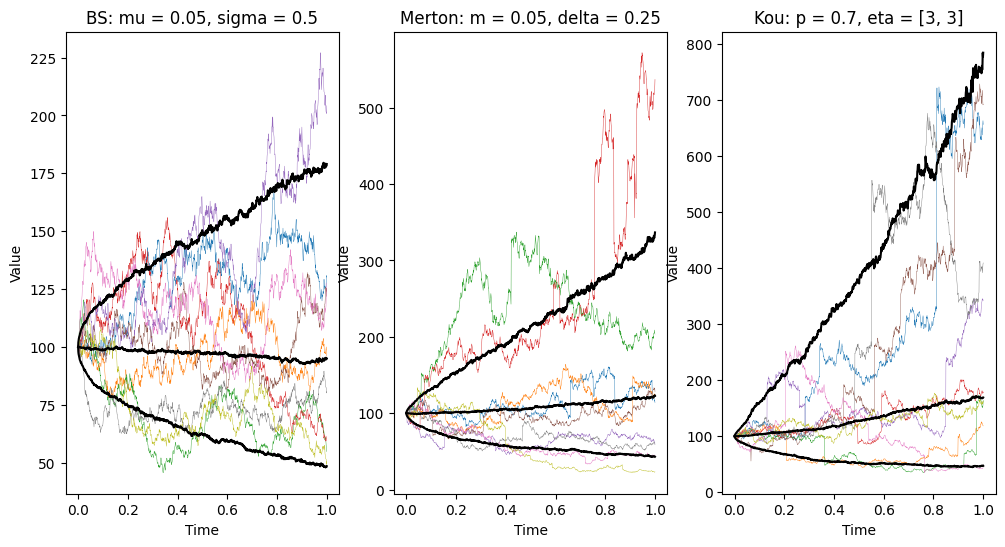

In [31]:
## Parameters
X0 = 100 #np.log(100)
mu = 0.05
sigma = 0.5
T = 1
Ndt = 1000
Nsims = 1000
# Merton
lam = 5
m = [0.01, 0.05]
delta = [0.05, 0.25]
# Kou
p = [0.5, 0.7]
eta = [[10, 10], [3, 3]]

## Figures - Moderate Parameters
fig_id = 0
fig, axes = plt.subplots(1, 3, figsize=(12,6), sharex=True)
np.random.seed(2502)

# BS
t, price = sim_jump_diffusion(X0, T, Ndt, mu, sigma, Nsims)
#price = np.exp(price)
# Plot the sample paths
axes[0].plot(t, price[:,1:10], linewidth=0.3)
axes[0].plot(t, np.quantile(price, [0.1, 0.5, 0.9], axis=1).transpose(), 
            linewidth=1.5, color='black')
axes[0].set_title("BS: " + r"mu = " + str(mu) + r", sigma = " + str(sigma))
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Value')

# Merton
t, price = sim_jump_diffusion(X0, T, Ndt, mu, sigma, Nsims, "Merton", lam, m = m[fig_id], delta = delta[fig_id])
# Plot the sample paths
axes[1].plot(t, price[:,1:10], linewidth=0.3)
axes[1].plot(t, np.quantile(price, [0.1, 0.5, 0.9], axis=1).transpose(), 
            linewidth=1.5, color='black')
axes[1].set_title("Merton: " + r"m = " + str(m[fig_id]) + r", delta = " + str(delta[fig_id]))
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Value')

# Kou
t, price = sim_jump_diffusion(X0, T, Ndt, mu, sigma, Nsims, "Kou", lam, p = p[fig_id], eta = eta[fig_id])
# Plot the sample paths
axes[2].plot(t, price[:,1:10], linewidth=0.3)
axes[2].plot(t, np.quantile(price, [0.1, 0.5, 0.9], axis=1).transpose(), 
            linewidth=1.5, color='black')
axes[2].set_title("Kou: " + r"p = " + str(p[fig_id]) + r", eta = " + str(eta[fig_id]))
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Value')

plt.show()

## Figures - Large Parameters
fig_id = 1
fig, axes = plt.subplots(1, 3, figsize=(12,6), sharex=True)
np.random.seed(2502)

# BS
t, price = sim_jump_diffusion(X0, T, Ndt, mu, sigma, Nsims)
# Plot the sample paths
axes[0].plot(t, price[:,1:10], linewidth=0.3)
axes[0].plot(t, np.quantile(price, [0.1, 0.5, 0.9], axis=1).transpose(), 
            linewidth=1.5, color='black')
axes[0].set_title("BS: " + r"mu = " + str(mu) + r", sigma = " + str(sigma))
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Value')

# Merton
t, price = sim_jump_diffusion(X0, T, Ndt, mu, sigma, Nsims, "Merton", lam, m = m[fig_id], delta = delta[fig_id])
# Plot the sample paths
axes[1].plot(t, price[:,1:10], linewidth=0.3)
axes[1].plot(t, np.quantile(price, [0.1, 0.5, 0.9], axis=1).transpose(), 
            linewidth=1.5, color='black')
axes[1].set_title("Merton: " + r"m = " + str(m[fig_id]) + r", delta = " + str(delta[fig_id]))
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Value')

# Kou
t, price = sim_jump_diffusion(X0, T, Ndt, mu, sigma, Nsims, "Kou", lam, p = p[fig_id], eta = eta[fig_id])
# Plot the sample paths
axes[2].plot(t, price[:,1:10], linewidth=0.3)
axes[2].plot(t, np.quantile(price, [0.1, 0.5, 0.9], axis=1).transpose(), 
            linewidth=1.5, color='black')
axes[2].set_title("Kou: " + r"p = " + str(p[fig_id]) + r", eta = " + str(eta[fig_id]))
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Value')

plt.show()

## Option Pricing

In [52]:
## Helper functions
# Black-Scholes
def call_BS(St, k, r, sigma, T, t = 0):
    dpos = (np.log(St/k) + (r + sigma**2/2)*(T - t))/(sigma * np.sqrt(T - t))
    dneg = (np.log(St/k) + (r - sigma**2/2)*(T - t))/(sigma * np.sqrt(T - t))
    return St * stats.norm.cdf(dpos) - k * np.exp(-r * (T - t)) * stats.norm.cdf(dneg)

# Merton
def call_Merton(lam, m, delta, St, k, r, sigma, T, t = 0):
    val = 0
    lam_bar = lam * np.exp(m + delta**2/2)
    delta_T = T - t
    for i in range(100):
        sigma_i = sigma**2 + (i * delta**2)/delta_T
        r_i = r - lam * (np.exp(m + delta**2/2) - 1) + i*(m + delta**2/2)/delta_T
        val += (lam_bar * delta_T)/np.math.factorial(i) * call_BS(St, k, r_i, sigma_i, T, t)
    return np.exp(-lam_bar) * val


# Tests
print(call_BS(50, np.arange(5) + 1, 0.05, 0.2, 1))

print(call_Merton(1, 0.1, 0.1, 50, np.arange(5) + 1, 0.05, 0.2, 1))

[49.04877058 48.09754115 47.14631173 46.1950823  45.24385288]
[48.75897543 47.80266766 46.84635988 45.89005211 44.93374433]


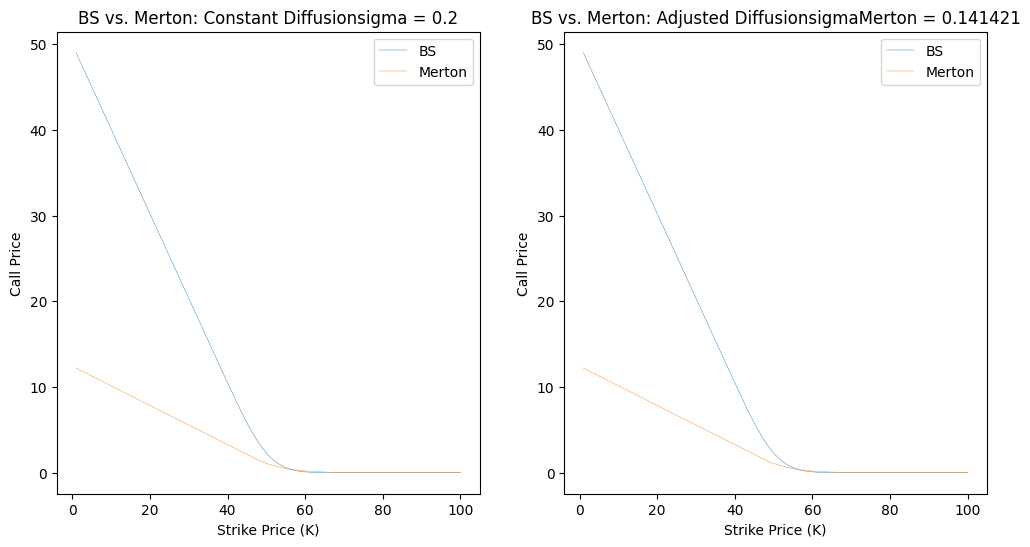

In [69]:
## Figures
# Parameters
St = 50
k = np.arange(0, 100) + 1
r = 0.05
T = 0.25
Ndt = 1000
sigma_BS = 0.2
# Merton
sigma_Merton = 0.141421
lam = 1
m = 0.1
delta = 0.1

# Call prices - Plots
np.random.seed(2502)
fig, axes = plt.subplots(1, 2, figsize=(12,6), sharex=True)

# Constant diffusion
price = np.transpose(np.array([call_BS(St, k, r, sigma_BS, T), call_Merton(lam, m, delta, St, k, r, sigma_BS, T)]))
# Plot the call price
axes[0].plot(k, price, linewidth=0.3, label = ["BS", "Merton"])
# axes[0].plot(t, np.quantile(price, [0.1, 0.5, 0.9], axis=1).transpose(), 
#             linewidth=1.5, color='black')
axes[0].set_title("BS vs. Merton: Constant Diffusion" + r"sigma = " + str(sigma_BS))
axes[0].set_xlabel('Strike Price (K)')
axes[0].set_ylabel('Call Price')
axes[0].legend()

# Adjusted diffusion
price = np.transpose(np.array([call_BS(St, k, r, sigma_BS, T), call_Merton(lam, m, delta, St, k, r, sigma_Merton, T)]))
# Plot the call price
axes[1].plot(k, price, linewidth=0.3, label = ["BS", "Merton"])
# axes[0].plot(t, np.quantile(price, [0.1, 0.5, 0.9], axis=1).transpose(), 
#             linewidth=1.5, color='black')
axes[1].set_title("BS vs. Merton: Adjusted Diffusion" + r"sigmaMerton = " + str(sigma_Merton))
axes[1].set_xlabel('Strike Price (K)')
axes[1].set_ylabel('Call Price')
axes[1].legend()

plt.show()